In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import matplotlib.gridspec as gridspec
import json
from itertools import combinations

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Charter", "Bitstream Charter"],
    "font.style": "normal",
})

## Characterize variance in per-sector age predictions for same star

In [2]:
model_folder = '/Users/philvanlane/Documents/lc_ae/final_model/parallel_fixed/e110/'
predictions = pd.read_csv(f'{model_folder}/age-inference-multiscale-predict_mean/kfold_predictions_per_sector.csv')

In [41]:
tics = np.unique(predictions['TIC_ID'].values)
true_ages = []
pred_means = []
pred_stds = []
num_sectors = []
diffs_all = []
for tic in tics:
    true_age = predictions[predictions['TIC_ID'] == tic]['true_age_myr'].values[0]
    pred_tic = predictions[predictions['TIC_ID'] == tic]
    preds = pred_tic['predicted_age_myr'].values
    pred_means.append(np.mean(preds))
    pred_stds.append(np.std(preds))
    num_sectors.append(len(pred_tic))
    true_ages.append(true_age)
    if len(pred_tic) > 1:
        diffs = [a - b for a, b in combinations(preds, 2)]
        diffs_all.extend(diffs)
diffs_all = np.array(diffs_all)

In [42]:
df = pd.DataFrame({
    'TIC_ID': tics,
    'true_age_myr': true_ages,
    'pred_mean': pred_means,
    'pred_std': pred_stds,
    'num_sectors': num_sectors,
})

In [43]:
df_multisector = df[df['num_sectors'] > 1]

In [44]:
df_multisector

,TIC_ID,true_age_myr,pred_mean,pred_std,num_sectors
0,590274,45.0,1.672853,0.112953,3
1,615133,42.0,1.566486,0.049730,2
2,627018,149.0,1.653514,0.000000,2
5,1028816,120.0,1.639009,0.006216,2
6,1031299,45.0,1.406937,0.180270,2
...,...,...,...,...,...
9214,1003518839,5.0,0.760450,0.101532,2
9215,1105040564,5.0,1.585135,0.894399,4
9216,1166537543,16.0,0.839189,0.188559,2
9220,1922376562,250.0,1.258438,0.202239,3


In [50]:
predictions.loc[predictions['TIC_ID'] == 627018]

,TIC_ID,sector,true_age_myr,predicted_age_myr,bprp0,fold
28973,627018,5,149.0,1.653514,2.596851,8
28974,627018,98,149.0,1.653514,2.596851,8


### Summary stats

In [45]:
print('Mean STDEV of multisector predictions: ', np.mean(np.std(df_multisector['pred_std'].values)))
print('Median STDEV of multisector predictions: ', np.median(np.std(df_multisector['pred_std'].values)))

Mean STDEV of multisector predictions:  0.21276472046562153
Median STDEV of multisector predictions:  0.21276472046562153


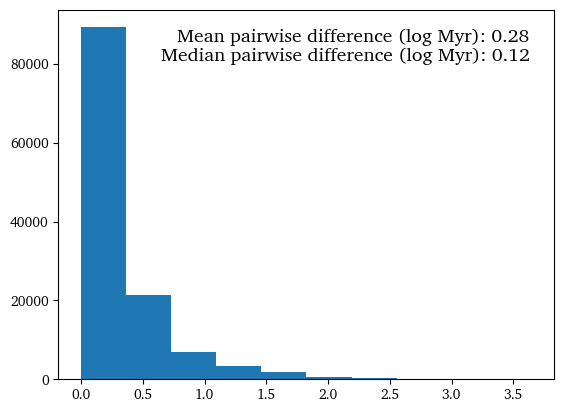

In [46]:
plt.hist(np.abs(diffs_all))
plt.text(0.95, 0.95, f'Mean pairwise difference (log Myr): {np.mean(np.abs(diffs_all)):.2f}\nMedian pairwise difference (log Myr): {np.median(np.abs(diffs_all)):.2f}',
          transform=plt.gca().transAxes, ha='right', va='top',fontsize=14)
plt.show()

### Look at variance by number of sectors

In [53]:
distinct_num_sectors = np.unique(df_multisector['num_sectors'].values)
num_sector_std = []
for n in distinct_num_sectors:
    subset = df_multisector[df_multisector['num_sectors'] == n]
    typical_std = np.mean(subset['pred_std'].values)
    num_sector_std.append(typical_std)

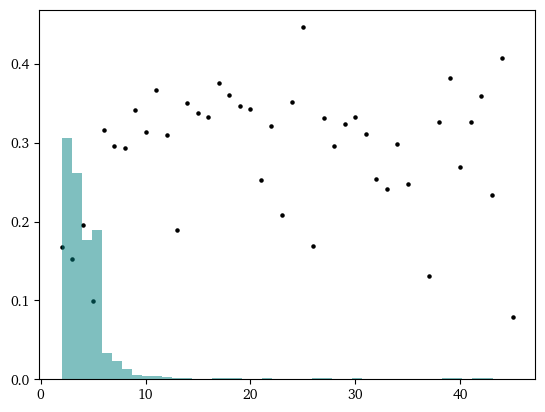

In [61]:
plt.scatter(distinct_num_sectors, num_sector_std,color='black',s=5)
plt.hist(df_multisector['num_sectors'].values, bins=45,density=True, alpha=0.5,color='teal')
plt.show()